In [1]:
import pandas as pd
import torch
from torch import nn
from sklearn.model_selection import train_test_split
from transformers import (
    AutoTokenizer,
    AutoModel,
    Trainer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    EarlyStoppingCallback
)
from datasets import Dataset as HFDataset
from evaluate import load as load_metric
from transformers import PreTrainedModel, AutoConfig

from transformers.modeling_outputs import SequenceClassifierOutput
from transformers import DataCollatorWithPadding


from huggingface_hub.utils import disable_progress_bars
disable_progress_bars()

import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["TRANSFORMERS_NO_ADVISORY_WARNINGS"] = "true"

# Pre train on LGBT
Train twhin-bert-base to recognize if the tweet+bio is written by a person part of the LGBT community.
It does not need to be 100% precise, as the LBGT truth labels are assigned by an LLM. This (freezed) model will be used 
as a second source of information during the true classification.

The idea is that a LGBT person is more likely to use slurs with reclamatory intent, and combining the downstream task with this additional source
of specific information can help the model determine whenever a slur is used with reclamatory intent

In [2]:
ita = pd.read_csv("dataset/augmented_it.csv")
#For the moment, it works only on italian
dataset = pd.concat([ita])
dataset['bio'] = dataset['bio'].fillna('')

In [3]:
dataset.head()

,id,text,bio,label,lang,lgbt
0,it_1231,La destra Italiana pur di non dire che loro od...,Il rispetto per il prossimo qualunque sia il s...,0,it,1
1,it_1713,"""Presupporre che tutti i bisessuali non sono m...",𝓕𝓲𝓵𝓵𝓮𝓭 𝔀𝓲𝓽𝓱 𝓯𝓾𝓻𝔂 𝓪𝓷𝓭 𝓼𝓽𝓪𝓻𝓻𝔂 𝓮𝔂𝓮𝓭,0,it,1
2,it_1474,"Se i diritti devono essere uguali, voglio che ...",User Experience Designer URL,0,it,0
3,it_58,che poi molti uomini trans subiscono lesbofobi...,"no matter where i go, you're there …",0,it,1
4,it_511,Che poi è l’etero medio come Pio e Amedeo che ...,T'appartengo ed io ci tengo \nE se prometto po...,0,it,0


It is very interesting to see that the `lgbt` label is not related with the `label` label. This is important because it really brings new informations to the table

In [4]:
dataset["label"].value_counts(normalize=True)

label
0    0.809392
1    0.190608
Name: proportion, dtype: float64

In [5]:
dataset["lgbt"].value_counts(normalize=True)

lgbt
1    0.604052
0    0.395948
Name: proportion, dtype: float64

70% training, 30% testing

In [6]:
pre_train_df, pre_test_df = train_test_split(
    dataset,
    test_size=0.3,
    stratify=dataset["lgbt"],
    random_state=42
)

In [7]:
model_name = "Twitter/twhin-bert-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

Here we tokenize both the text of the tweet and the bio

In [8]:
def tokenize(batch):
    return tokenizer(
        batch["text"],
        batch["bio"],
        truncation=True,
        padding="max_length",
        max_length=128, # Lunghezza massima per i testi
    )

In [9]:
train_ds = HFDataset.from_pandas(pre_train_df).map(tokenize, batched=True)
test_ds = HFDataset.from_pandas(pre_test_df).map(tokenize, batched=True)

Map:   0%|          | 0/760 [00:00<?, ? examples/s]

Map:   0%|          | 0/326 [00:00<?, ? examples/s]

In [10]:
train_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
test_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

Computing the class weights to weight the loss

In [11]:
label_counts = pre_train_df["lgbt"].value_counts().to_dict()
total = sum(label_counts.values())
weights = [total / label_counts[i] for i in sorted(label_counts.keys())]
class_weights = torch.tensor(weights, dtype=torch.float)
print(f"Class weights: {class_weights}")

Class weights: tensor([2.5249, 1.6558])


In [12]:
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2).to("cuda")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at Twitter/twhin-bert-base and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


We use this class instead of the vanilla Trainer so we can employ the weighted loss

In [13]:
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = nn.CrossEntropyLoss(weight=class_weights.to(model.device))
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

f1 score is the official metric for the task

In [14]:
accuracy_metric = load_metric("accuracy")
f1_metric = load_metric("f1")

In [15]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = torch.argmax(torch.tensor(logits), dim=-1)
    return {
        "accuracy": accuracy_metric.compute(predictions=preds, references=labels)["accuracy"],
        "f1": f1_metric.compute(predictions=preds, references=labels)["f1"],
    }

### TODO: finetune hyperparameters

In [16]:
training_args = TrainingArguments(
    output_dir="./results_weighted",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=8,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_dir="./logs_weighted",
    logging_steps=50,
    save_total_limit=2,
)

In [17]:
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

/tmp/ipykernel_74602/4027745582.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `WeightedTrainer.__init__`. Use `processing_class` instead.
  trainer = WeightedTrainer(


In [18]:
trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 0, 'pad_token_id': 1}.
BertSdpaSelfAttention is used but `torch.nn.functional.scaled_dot_product_attention` does not support non-absolute `position_embedding_type` or `output_attentions=True` or `head_mask`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.370400,0.302831,0.917178,0.756757
2,0.124100,0.289954,0.932515,0.819672
3,0.225700,0.305845,0.926380,0.809524
4,0.143700,0.405936,0.923313,0.803150
5,0.036100,0.423187,0.929448,0.818898
6,0.000300,0.465620,0.929448,0.818898
7,0.000200,0.479277,0.929448,0.818898
8,0.014400,0.474328,0.929448,0.818898


TrainOutput(global_step=1520, training_loss=0.07726315168915071, metrics={'train_runtime': 110.8044, 'train_samples_per_second': 54.871, 'train_steps_per_second': 13.718, 'total_flos': 399928804147200.0, 'train_loss': 0.07726315168915071, 'epoch': 8.0})

Now `trainer.model` contains our best finetuned model to detect whenever a person is likely to be LGBT or not. As we can see, the best iteraction obtains $0.86$ f1 score and $0.94$ accuracy. This precision is more than enought to bring complementary informations 

# Double pipeline

In [19]:
class DualEncoderForSequenceClassification(PreTrainedModel):
    config_class = AutoConfig
    def __init__(self, config):
        super().__init__(config)
        self.num_labels = config.num_labels
        self.encoder_text = AutoModel.from_config(config)
        self.encoder_bio = AutoModel.from_config(config)
        hidden_size = config.hidden_size

        # Gating layer: it weights the two source of informations for the final classification
        self.gate_layer = nn.Sequential(
            nn.Linear(hidden_size * 2, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),
            nn.Sigmoid()
        )

        # Final classifier
        self.dropout = nn.Dropout(config.hidden_dropout_prob)
        self.classifier = nn.Linear(hidden_size, config.num_labels)

        self.post_init()

    def forward(
        self,
        input_ids=None,
        attention_mask=None,
        labels=None,
        return_dict=None,
    ):
        return_dict = return_dict if return_dict is not None else self.config.use_return_dict

        outputs_text = self.encoder_text(
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_dict=return_dict,
        )
        outputs_bio = self.encoder_bio(
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_dict=return_dict,
        )

        #Obtain last hidden state of the bert model
        h_text = outputs_text.last_hidden_state[:, 0]
        h_bio = outputs_bio.last_hidden_state[:, 0]

        #Concat the hidden states
        combined = torch.cat((h_text, h_bio), dim=-1)
        #Gate the informations
        gate = self.gate_layer(combined) 
        h_final = gate * h_text + (1 - gate) * h_bio

        # Classification
        pooled_output = self.dropout(h_final)
        logits = self.classifier(pooled_output)

        # Loss computation
        loss = None
        if labels is not None:
            if hasattr(self.config, 'class_weights') and self.config.class_weights is not None:
                class_weights = torch.tensor(self.config.class_weights, device=self.device)
            else:
                class_weights = None
            loss_fct = nn.CrossEntropyLoss(weight=class_weights)
            loss = loss_fct(logits.view(-1, self.num_labels), labels.view(-1))

        if not return_dict:
            output = (logits,)
            return ((loss,) + output) if loss is not None else output

        return SequenceClassifierOutput(
            loss=loss,
            logits=logits,
        )

In [20]:
train_df, test_df = train_test_split(
    dataset,
    test_size=0.3,
    stratify=dataset["label"],
    random_state=42
)

In [21]:
train_ds = HFDataset.from_pandas(train_df).map(tokenize, batched=True)
test_ds = HFDataset.from_pandas(test_df).map(tokenize, batched=True)
train_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
test_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

Map:   0%|          | 0/760 [00:00<?, ? examples/s]

Map:   0%|          | 0/326 [00:00<?, ? examples/s]

In [22]:
label_counts = pre_train_df["lgbt"].value_counts().to_dict()
total = sum(label_counts.values())
weights = [total / label_counts[i] for i in sorted(label_counts.keys())]
class_weights = torch.tensor(weights, dtype=torch.float)
print(f"Class weights: {class_weights}")

Class weights: tensor([2.5249, 1.6558])


In [23]:
config = AutoConfig.from_pretrained(model_name, num_labels=2)
config.class_weights = class_weights.tolist()
combined_model = DualEncoderForSequenceClassification(config)

In [24]:
base_model = AutoModel.from_pretrained(model_name)
combined_model.encoder_text.load_state_dict(base_model.state_dict())
state_dict = trainer.model.state_dict()
filtered_state_dict = {k.replace("bert.", ""): v for k, v in state_dict.items() if k.startswith("bert.")}
combined_model.encoder_bio.load_state_dict(filtered_state_dict, strict=False)

Some weights of BertModel were not initialized from the model checkpoint at Twitter/twhin-bert-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


<All keys matched successfully>

In [25]:
for param in combined_model.encoder_bio.parameters():
    param.requires_grad = False

In [26]:
del trainer.model, trainer
import gc
gc.collect()
torch.cuda.empty_cache()

In [27]:
combined_model.to("cuda")

DualEncoderForSequenceClassification(
  (encoder_text): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(250002, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
              (distance_embedding): Embedding(1023, 64)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features

### TODO: finetune

any kind of normalization lower the F1 score. This might actually be OK since it lowers the confidence of the model.

The wrong detected tweet are kinda bordeline, so lowering its confidence on out-of-distribution or strangely labelled tweet might be good

to be tested

In [ ]:
training_args = TrainingArguments(
    output_dir="./results_weighted",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    #gradient_accumulation_steps=2, #Since higly unbalanced, this should provide also negative examples
    per_device_eval_batch_size=4,
    num_train_epochs=8,
    weight_decay=0.1,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_dir="./logs_weighted",
    logging_steps=50,
    save_total_limit=2,
    #label_smoothing_factor=0.1,
)

# 

In [29]:
trainer = Trainer(
    model=combined_model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)] 
)

/tmp/ipykernel_74602/2826137177.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [30]:
trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 0, 'pad_token_id': 1}.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.254052,0.969325,0.916667
2,0.337200,0.249930,0.969325,0.916667
3,0.278800,0.259631,0.972393,0.925620
4,0.247100,0.261877,0.966258,0.912000
5,0.229200,0.270788,0.966258,0.909091
6,0.214800,0.277533,0.960123,0.888889


TrainOutput(global_step=288, training_loss=0.25427241292264724, metrics={'train_runtime': 67.4284, 'train_samples_per_second': 90.17, 'train_steps_per_second': 5.695, 'total_flos': 606090031718400.0, 'train_loss': 0.25427241292264724, 'epoch': 6.0})

# Results analysis

In [31]:
import numpy as np
from scipy.special import softmax

predictions_output = trainer.predict(test_ds)


print("Test set metrics:")
print(predictions_output.metrics)

logits = predictions_output.predictions
true_labels = predictions_output.label_ids
predicted_labels = np.argmax(logits, axis=-1)

# Compute the confidence of the model 
probabilities = softmax(logits, axis=1)
confidence_scores = np.max(probabilities, axis=1)

results_df = test_df.copy()

results_df['predicted_label'] = predicted_labels
results_df['true_label'] = true_labels
results_df['confidence'] = confidence_scores

results_df['is_correct'] = (results_df['true_label'] == results_df['predicted_label'])

output_filename = "error_analysis_results.csv"
results_df.to_csv(output_filename, index=False, encoding='utf-8-sig')

print(f"\nRisultati salvati in '{output_filename}'")
print("\nAnteprima del DataFrame con i risultati:")
results_df.head()

Test set metrics:
{'test_loss': 0.259631484746933, 'test_accuracy': 0.9723926380368099, 'test_f1': 0.9256198347107438, 'test_runtime': 1.2684, 'test_samples_per_second': 257.019, 'test_steps_per_second': 64.649}

Risultati salvati in 'error_analysis_results.csv'

Anteprima del DataFrame con i risultati:


,id,text,bio,label,lang,lgbt,predicted_label,true_label,confidence,is_correct
243,it_1491,@USER Non tacciate #katiaricciarelli di omofob...,Laureato in Scienze Politiche e delle Relazion...,0,it,0,0,0,0.937962,True
863,it_774,"@USER @USER Per qualcuno sono gay,per altri tr...",,1,it,0,0,1,0.959631,False
733,it_509,Tw // transfobia\n\nporcodio io cerco di non p...,"#MADSEASON : I'm above, over you I'm standing ...",0,it,1,0,0,0.967404,True
1,it_1713,"""Presupporre che tutti i bisessuali non sono m...",𝓕𝓲𝓵𝓵𝓮𝓭 𝔀𝓲𝓽𝓱 𝓯𝓾𝓻𝔂 𝓪𝓷𝓭 𝓼𝓽𝓪𝓻𝓻𝔂 𝓮𝔂𝓮𝓭,0,it,1,0,0,0.965948,True
592,it_300,con queste modifiche vogliono tagliare fuori l...,#loki: a bit of both ...,0,it,1,0,0,0.966977,True


In [32]:
# Shows only errors
errors_df = results_df[results_df['is_correct'] == False].copy()

print(f"{len(errors_df)}/{len(results_df)} errors.")

def print_error_details(dataframe):
    if dataframe.empty:
        return
        
    for index, row in dataframe.iterrows():
        print("-" * 50)
        print(f"Confidence: {row['confidence']:.2%}")
        print(f"True label:    {row['true_label']}")
        print(f"Predicted label: {row['predicted_label']}")
        print(f"Text:\n\"{row['text']}\"")
        print("-" * 50 + "\n")

# Errors with high confidence
N = 5
high_confidence_errors = errors_df.sort_values(by='confidence', ascending=False).head(N)

print("\n" + "="*20 + " TOP 5 ERRORS WITH HIGH CONFIDENCE " + "="*20)
print_error_details(high_confidence_errors)


low_confidence_errors = errors_df.sort_values(by='confidence', ascending=True).head(N)
print("\n" + "="*20 + " TOP 5 ERRORS LOW CONFIDENCE " + "="*20)
print_error_details(low_confidence_errors)


9/326 errors.

==================== TOP 5 ERRORS WITH HIGH CONFIDENCE ====================
--------------------------------------------------
Confidence: 95.96%
True label:    1
Predicted label: 0
Text:
"@USER @USER Per qualcuno sono gay,per altri transgender, per latri ancora LGBT. Per so froci e rottinculo! Bloccatemi vigliacchi di Twitter"
--------------------------------------------------

--------------------------------------------------
Confidence: 95.19%
True label:    1
Predicted label: 0
Text:
"@USER siamo froci ma non coglioni, eh. In Iran le persone lgbt hanno il dovere primario di salvarsi le vite.
Ma poi, cos'è, ti piacerebbe che anche qui ci arrestassero perché siamo froci? E' un velato augurio di morte? Suuuper cristiano!"
--------------------------------------------------

--------------------------------------------------
Confidence: 88.69%
True label:    0
Predicted label: 1
Text:
"Ieri sono uscito con una tuta arcobaleno e un tipo mi fa "frocio se vuoi ti faccio con

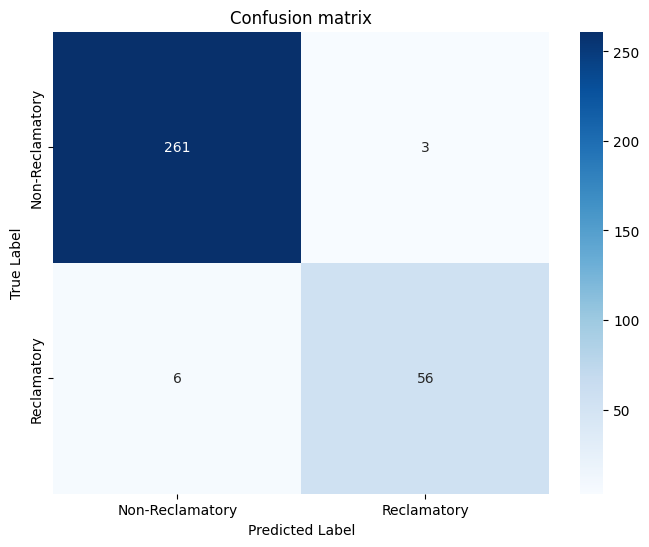

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(true_labels, predicted_labels)

class_labels = ['Non-Reclamatory', 'Reclamatory']

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_labels, yticklabels=class_labels)

plt.title('Confusion matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.show()